# WTC11 exact 19-nt guide mapping

Uses both `data/wtc11.hap*.mhc_contigs.fa` inputs and the cached GRCh38 alignments.
Select the **mambaforge Python environment** as the kernel. Run from the repo root.
See [WTC11_REPORT.md](WTC11_REPORT.md) for interpretation and caveats.

The default displays existing results. Set `RUN_PIPELINE=True` to regenerate;
set `REUSE_ALIGNMENTS=False` for a fresh alignment run.

In [1]:
from pathlib import Path
import sys, subprocess
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
assert (ROOT / 'run_wtc11_analysis.py').exists(), 'Run from the repository root'
OUT = ROOT / 'results/wtc11'
print('Python:', sys.executable)
RUN_PIPELINE = False
REUSE_ALIGNMENTS = True
if RUN_PIPELINE:
    command = [sys.executable, str(ROOT / 'run_wtc11_analysis.py'), '--threads', '8']
    if REUSE_ALIGNMENTS:
        command.append('--reuse-alignments')
    subprocess.run(command, check=True)
assert (OUT / 'loss_summary.tsv').exists(), 'Run the pipeline first'


Python: /Users/aeb84/software/miniforge3/envs/mambaforge/bin/python


## Haplotype assemblies and guide losses

In [2]:
display(pd.read_csv(OUT / 'assembly_contig_summary.tsv', sep='\t'))
display(pd.read_csv(OUT / 'loss_summary.tsv', sep='\t'))

,haplotype,contig,length,n_bases
0,hap1,hap1_h1tg000020l,61671305,0
1,hap2,hap2_h2tg000025l,32322129,0


,cohort,reference,total,missing,loss_percent
0,realigned,WTC11_hap1_MHC,11253,841,7.473563
1,intended,WTC11_hap1_MHC,11253,841,7.473563
2,realigned,WTC11_hap2_MHC,11253,759,6.744868
3,intended,WTC11_hap2_MHC,11253,759,6.744868
4,realigned,WTC11_MHC,11253,475,4.221097
5,intended,WTC11_MHC,11253,475,4.221097


## Guide lookup

The historical gap flag is a local sequence-match heuristic, not a confirmed assembly gap. Single-haplotype matches do not establish hemizygosity or activity.

In [3]:
lookup = pd.read_csv(OUT / 'guide_mapping_lookup.tsv.gz', sep='\t')
display(lookup.mapping_class.value_counts().to_frame('guide_rows'))
display(lookup.loc[lookup.n_hg38_mhc_loci > 0, 'wtc11_haplotypes'].value_counts().to_frame('guide_rows'))
display(lookup.loc[lookup.mapping_class == 'missing_in_WTC11', ['missing_reason', 'absence_in_assembly_gap']].value_counts().to_frame('guide_rows'))

,guide_rows
mapping_class,
unique_both,9818
non_targeting,1262
hemizygous_WTC11,554
missing_in_WTC11,475
multi_hg38,253
outside_WTC11_assembly,110
hemizygous_assembly_gap,78
multi_WTC11,75


,guide_rows
wtc11_haplotypes,
both,10128
neither,475
hap2_only,366
hap1_only,284


,,guide_rows
missing_reason,absence_in_assembly_gap,
snv_or_small_indel,False,355
deletion_in_both_haplotypes,True,33
deletion_in_one_haplotype,True,30
snv_or_small_indel,True,26
insertion_in_WTC11,True,14
deletion_in_both_haplotypes,False,10
insertion_in_WTC11,False,7


## Spatial losses in either haplotype

Counts use the combined haplotype presence. Stars reflect the inherited binomial density model with full BH adjustment; spatially adjacent guides are not independent biological replicates.

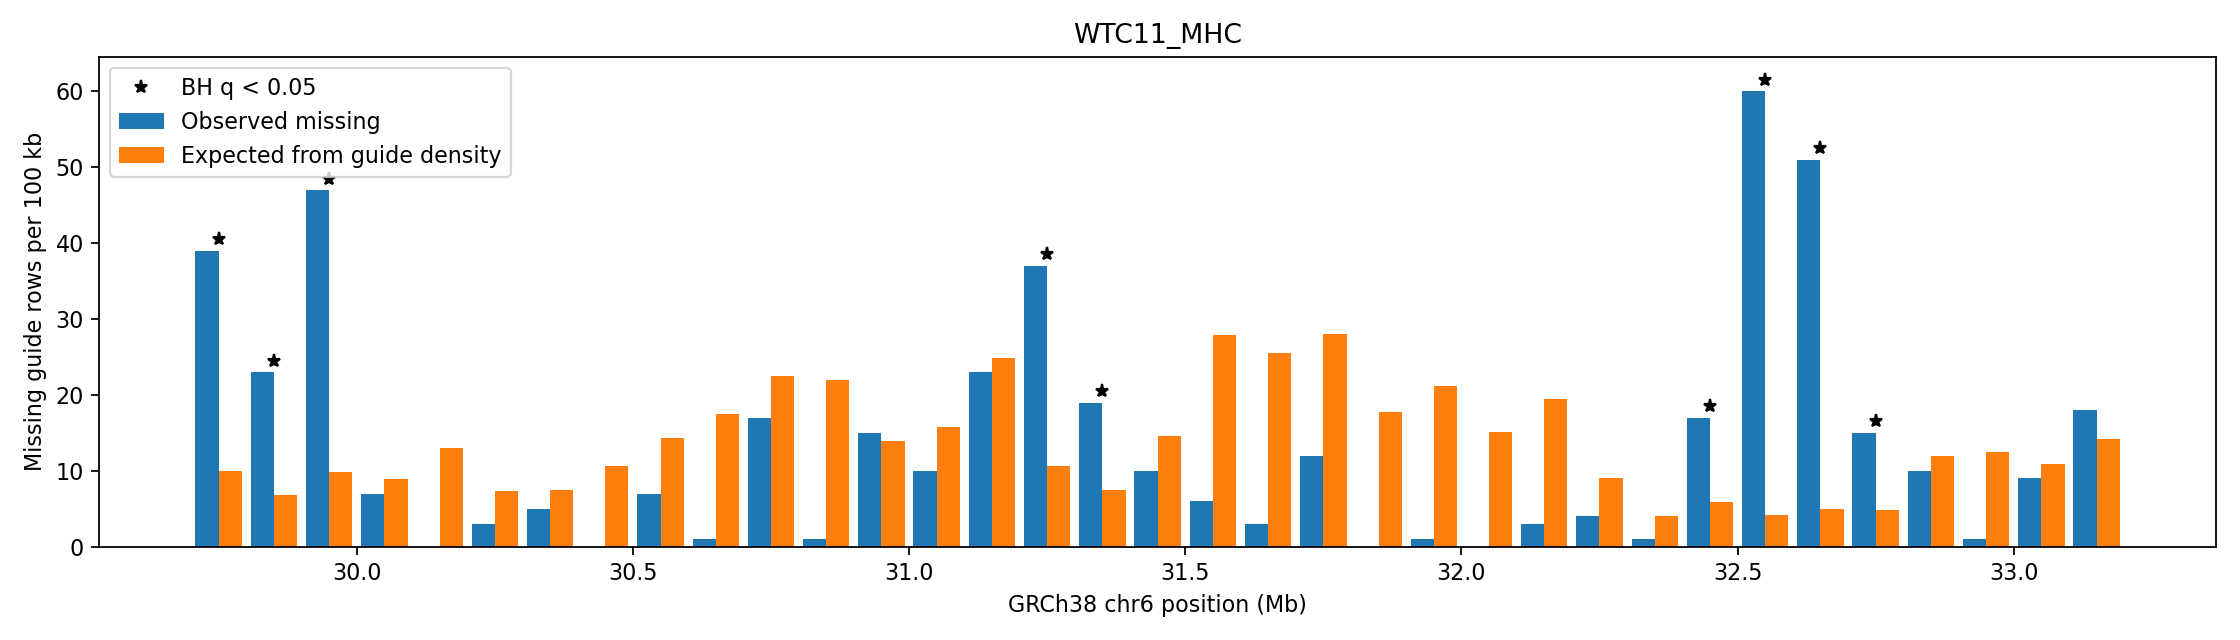

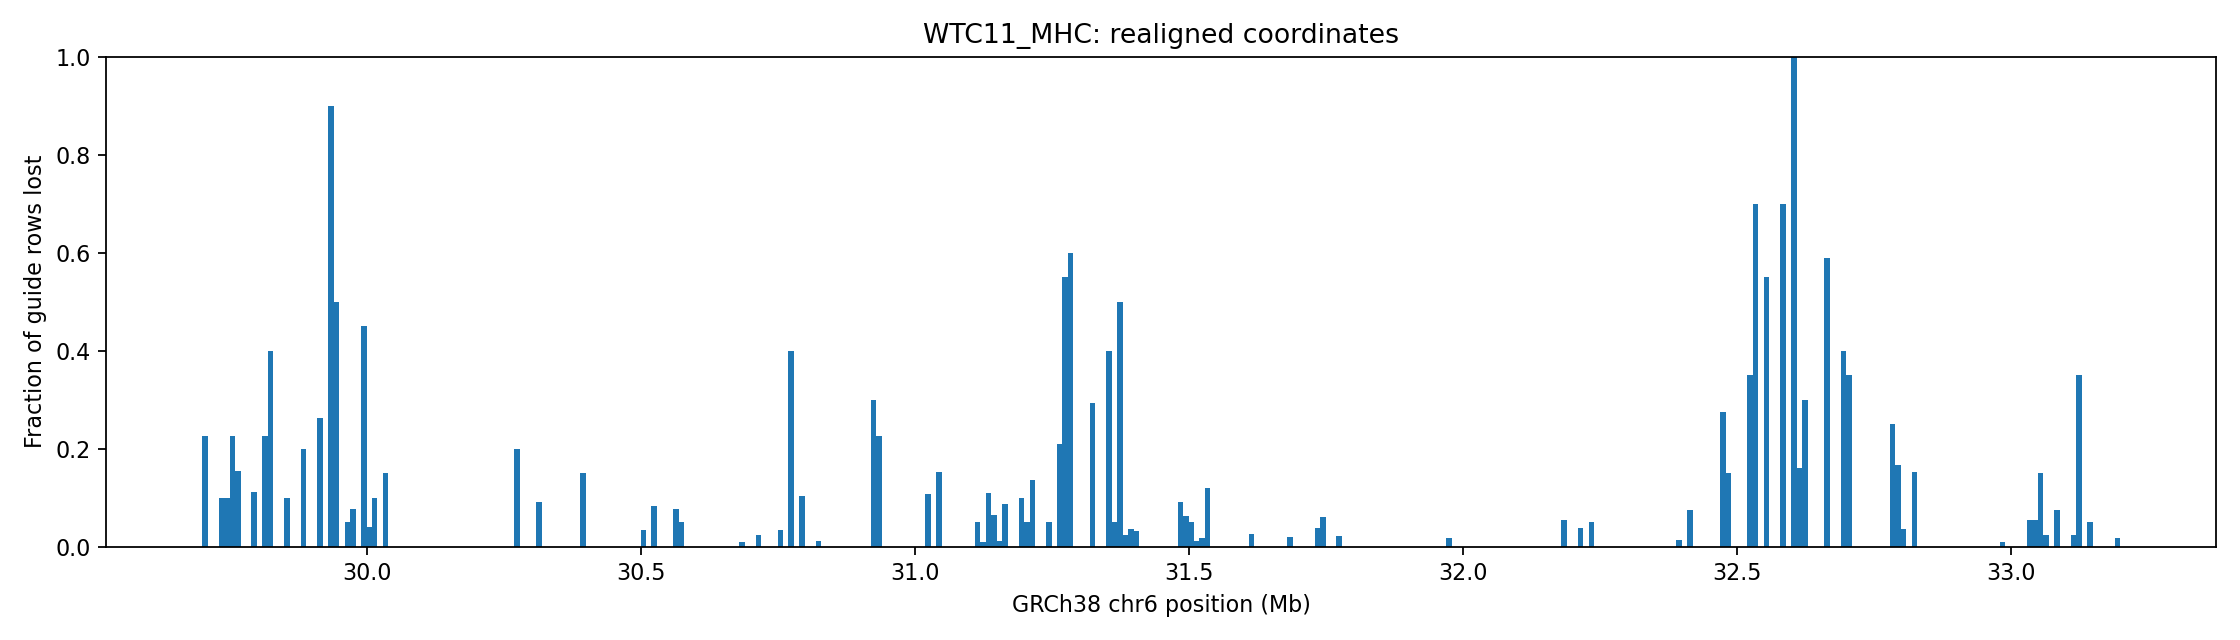

In [4]:
display(Image(filename=str(OUT / 'realigned/WTC11_MHC/missing_observed_vs_expected.png')))
display(Image(filename=str(OUT / 'realigned/WTC11_MHC/loss_fraction.png')))

## WTC11 versus K562 on the same GRCh38 MHC cohort

In [5]:
display(pd.read_csv(OUT / 'k562_wtc11_presence_counts.tsv', sep='\t'))

,present_K562,present_WTC11,guide_rows
0,False,False,258
1,False,True,72
2,True,False,217
3,True,True,10706


## iPSC and NPC screen checks

Counts are top-guide **slots**, which can repeat guides across genes/screens. The historical review flags are retained; exact absence does not demonstrate inactivity.

In [6]:
screens = pd.read_csv(OUT / 'screen_problem_guide_summary.tsv', sep='\t')
display(screens)
flagged = pd.read_csv(OUT / 'fractel_hits_with_problem_guides.tsv', sep='\t')
display(flagged[['screen', 'dhs', 'gene_symbol', 'guide_id', 'guide_rank', 'mapping_class', 'absence_in_assembly_gap']])

,screen,dhs_gene_pairs,fractel_hits,top_slots,bg_pct_relevant,hit_top_slots,hit_relevant_problem,hit_pct_relevant,hit_pairs_with_problem,hit_hemizygous,hit_pairs_all_hemizygous
0,ipsc.krab,62176,153,180056,7.006242,459,23,5.010893,14,23,1
1,ipsc.p300,68230,26,198876,6.970392,78,7,8.974359,5,4,0
2,npc.krab,55477,80,159863,7.049736,240,5,2.083333,3,5,0
3,npc.p300,63313,61,182665,7.051106,183,7,3.825137,5,9,0


,screen,dhs,gene_symbol,guide_id,guide_rank,mapping_class,absence_in_assembly_gap
0,ipsc.krab,chr6:29887280-29888879,HLA-A,chr6:29888483:29888503_+_GTGATGTATGGCTGCGACGT,1,multi_WTC11,False
1,ipsc.krab,chr6:29917733-29918203,POU5F1,chr6:29918120:29918140_-_GACGATATGGTGAGGGAGGT,1,missing_in_WTC11,False
2,ipsc.krab,chr6:29917733-29918203,POU5F1,chr6:29918127:29918147_-_CCTGTCAGACGATATGGTGA,2,missing_in_WTC11,False
3,ipsc.krab,chr6:29924848-29925041,HLA-A,chr6:29924853:29924873_+_GAAGCTTCACAAGACCGAGG,1,multi_hg38,False
4,ipsc.krab,chr6:29934071-29934293,HLA-A,chr6:29934202:29934222_+_CAGCAGACAGCCTACCTGGA,1,missing_in_WTC11,False
5,ipsc.krab,chr6:29934071-29934293,HLA-A,chr6:29934191:29934211_-_TGTCTGCTGCTCCGCCTCAT,2,missing_in_WTC11,False
6,ipsc.krab,chr6:29934071-29934293,HLA-A,chr6:29934206:29934226_+_AGACAGCCTACCTGGAGGGC,3,missing_in_WTC11,False
7,ipsc.krab,chr6:29941886-29943609,HLA-A,chr6:29942397:29942417_-_CAGGATGAAGGACCCTACGT,3,missing_in_WTC11,False
8,ipsc.krab,chr6:30006203-30006475,HLA-A,chr6:30006440:30006460_+_CTGCGACGGGTCCTTCTTCC,1,multi_hg38,False
9,ipsc.krab,chr6:31270985-31272710,HLA-C,chr6:31272264:31272284_-_ATTGGGGAGGCGCCGCGTTG,2,missing_in_WTC11,True


## Validate all exact placements and accounting

In [7]:
subprocess.run([sys.executable, str(ROOT / 'validate_wtc11_results.py')], check=True)

.
----------------------------------------------------------------------
Ran 1 test in 0.007s

OK


hap1: verified all 10,893 exact placements directly against FASTA
hap2: verified all 10,640 exact placements directly against FASTA
Passed: input hashes, guide IDs/counts, union logic, lookup joins, loss windows/clusters, BH monotonicity, WTC11 screen scope


CompletedProcess(args=['/Users/aeb84/software/miniforge3/envs/mambaforge/bin/python', '/Users/aeb84/workspace/Gersbachlab-Bioinformatics/ExploreMHC_K562nWTC11/validate_wtc11_results.py'], returncode=0)